In [1]:
import io
import textwrap

import beaker
import faceted
import numpy as np
import pandas as pd
import xarray as xr

import plotting

In [2]:
TEST_PREFIX = "test"
TRAIN_VALIDATE_PREFIX = "train-and-validate"


def open_beaker_dataset(dataset_id: str, path: str) -> xr.Dataset:
    """Given a beaker dataset ID and path within dataset, return an xarray
    dataset.

    Note: dataset must fit in memory. Requires h5netcdf backend.  Adapted from
    ace2-paper repo.
    """
    client = beaker.Beaker.from_env()
    file = client.dataset.get_file(dataset_id, path)
    ds = xr.open_dataset(io.BytesIO(file), engine="h5netcdf").load()
    if "source" in ds.dims:
        ds = ds.sel(source="target").drop_vars("source")
    return ds


def open_precombined_datasets(cases: dict[str, str], path: str) -> xr.Dataset:
    datasets = {}
    for case, dataset_id in cases.items():
        ds = open_beaker_dataset(dataset_id, path)
        ds = ds.assign_coords(sample=range(1, ds.sizes["sample"] + 1))
        datasets[case] = ds
    return xr.concat(datasets.values(), dim=pd.Index(cases.keys(), name="model"))


def open_datasets(precombined_cases: dict[str, str], path: str) -> xr.Dataset:
    train_and_validate = open_precombined_datasets(precombined_cases, f"{TRAIN_VALIDATE_PREFIX}/{path}")
    test = open_precombined_datasets(precombined_cases, f"{TEST_PREFIX}/{path}")
    return xr.concat([train_and_validate, test], dim="year").squeeze("sample")

In [3]:
DATASETS = {
    "SHiELD": "01KMGN2SPW5SRDSZMXYZ27D1AJ",
    "SHiELD-historical-co2": "01KMGK3MDY5T575NKP62S09YYQ",
    "ACE2-SHiELD": "01KMJMT8549XGYZ2E7YZ3BEXGK",
    "ACE2S-SHiELD w/o random CO$_2$ w/ energy conservation": "01KMJMT8BRANS646CYAJ48H5Z4",
    "ACE2S-SHiELD w/ random CO$_2$ w/ energy conservation": "01KMGTF0PEM2TFTWG5G22MBJ1E",
}


In [4]:
ds = open_datasets(DATASETS, "annual_diagnostics.nc")

/home/spencerc/ace2s-shield-plus-paper/manuscript/.pixi/envs/default/lib/python3.13/site-packages/beaker/util.py:25: RuntimeWarning: Found unknown field 'budget: 01HPM52AQCRXMD5BPZAMJG3TDZ' for data model 'Workspace'. This may be a newly added field that hasn't been defined in beaker-py yet. Please submit an issue report about this here:
https://github.com/allenai/beaker-py/issues/new?assignees=&labels=bug&template=bug_report.yml
  warnings.warn(
/home/spencerc/ace2s-shield-plus-paper/manuscript/.pixi/envs/default/lib/python3.13/site-packages/beaker/util.py:25: RuntimeWarning: Found unknown field 'budget: 01HPM52AQCRXMD5BPZAMJG3TDZ' for data model 'Dataset'. This may be a newly added field that hasn't been defined in beaker-py yet. Please submit an issue report about this here:
https://github.com/allenai/beaker-py/issues/new?assignees=&labels=bug&template=bug_report.yml
  warnings.warn(


Output()

Output()

Output()

Output()

...

Output()

Output()

Output()

Output()

Output()

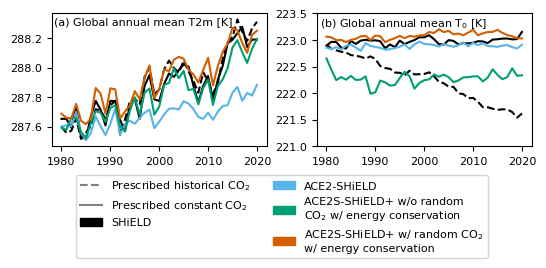

In [34]:
plotting.configure_style(fontsize=8)

fig, (ax1, ax2) = faceted.faceted(1, 2, width=5.5, aspect=0.618, sharey=False, internal_pad=0.5, left_pad=0.45, bottom_pad=1.2)

ds.TMP2m.sel(model="SHiELD").plot(ax=ax1, color="k")
ds.TMP2m.sel(model="SHiELD-historical-co2").plot(ax=ax1, color="k", linestyle="--")
ds.TMP2m.sel(model="ACE2-SHiELD").plot(ax=ax1, color="C0")
ds.TMP2m.sel(model="ACE2S-SHiELD w/o random CO$_2$ w/ energy conservation").plot(ax=ax1, color="C2")
ds.TMP2m.sel(model="ACE2S-SHiELD w/ random CO$_2$ w/ energy conservation").plot(ax=ax1, color="C4")

ds.air_temperature_0.sel(model="SHiELD").plot(ax=ax2, color="k", label="SHiELD")
ds.air_temperature_0.sel(model="SHiELD-historical-co2").plot(ax=ax2, color="k", linestyle="--", label=None)
ds.air_temperature_0.sel(model="ACE2-SHiELD").plot(ax=ax2, color="C0", label="ACE2-SHiELD")
ds.air_temperature_0.sel(model="ACE2S-SHiELD w/o random CO$_2$ w/ energy conservation").plot(ax=ax2, color="C2", label="ACE2S-SHiELD+ w/o random CO$_2$ w/ energy conservation")
ds.air_temperature_0.sel(model="ACE2S-SHiELD w/ random CO$_2$ w/ energy conservation").plot(ax=ax2, color="C4", label="ACE2S-SHiELD+ w/ random CO$_2$ w/ energy conservation")

for ax in (ax1, ax2):
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_title("")

ax2.set_ylim(221, 223.5)


import matplotlib.lines as mlines
import matplotlib.patches as mpatches


gray_solid = mlines.Line2D(
    [], [], color="gray", linestyle="--", label="Prescribed historical CO$_2$"
)
gray_dashed = mlines.Line2D(
    [], [], color="gray", linestyle="-", label="Prescribed constant CO$_2$"
)

shield_patch = mpatches.Patch(color="k", label="SHiELD")
ace2_shield_patch = mpatches.Patch(color="C0", label="ACE2-SHiELD")
ace2s_shield_w_o_random_co2_patch = mpatches.Patch(color="C2", label="ACE2S-SHiELD+ w/o random CO$_2$ w/ energy conservation")
ace2s_shield_w_random_co2_patch = mpatches.Patch(color="C4", label="ACE2S-SHiELD+ w/ random CO$_2$ w/ energy conservation")

handles = [gray_solid, gray_dashed, shield_patch, ace2_shield_patch, ace2s_shield_w_o_random_co2_patch, ace2s_shield_w_random_co2_patch]
labels = ["Prescribed historical CO$_2$", "Prescribed constant CO$_2$", "SHiELD", "ACE2-SHiELD", textwrap.fill("ACE2S-SHiELD+ w/o random CO$_2$ w/ energy conservation", width=30), textwrap.fill("ACE2S-SHiELD+ w/ random CO$_2$ w/ energy conservation", width=30)]

fig.legend(
    handles=handles,
    labels=labels,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.01),
    ncol=2,
    frameon=True
)

ax1.annotate(
    "(a) Global annual mean T2m [K]",
    xy=(0, 1),
    xytext=(2, -2),
    va="top",
    xycoords="axes fraction",
    textcoords="offset points",
)
ax2.annotate(
    textwrap.fill("(b) Global annual mean T$_0$ [K]", width=50),
    xy=(0, 1),
    xytext=(2, -2),
    va="top",
    xycoords="axes fraction",
    textcoords="offset points",
)

fig.patch.set_alpha(0)
fig.savefig("figure-05.png", dpi=200)
fig.savefig("figure-05.pdf")
